# Tox21 Classical Baseline Notebook

This notebook builds a production-style baseline for the Tox21 multi-task toxicity benchmark using classical machine learning only.

## What it does
- Loads the local `tox21.csv` file
- Builds ECFP / Morgan fingerprints with fixed length
- Uses a scaffold split for realistic generalization
- Trains one Random Forest classifier per toxicity task
- Applies SMOTEENN only on the training split of each task
- Reports ROC-AUC per task, mean ROC-AUC, and supporting metrics
- Includes a compact XGBoost comparison for one representative task

## Why scaffold split matters
Molecules with the same core scaffold tend to behave similarly. A random split can leak close analogs into both train and test, making the model look better than it really is. A scaffold split keeps similar chemotypes together, so the evaluation is closer to what happens in drug discovery.

## Why the dataset is imbalanced
Tox21 endpoints are sparse by nature: most compounds are non-toxic for most assays, and only a small fraction are active. That class skew makes accuracy misleading, so this notebook focuses on ROC-AUC and task-wise imbalance handling.

## Why SMOTEENN
SMOTE alone creates synthetic minority samples, but it can also preserve borderline or noisy majority samples. SMOTEENN combines oversampling with Edited Nearest Neighbors, which both increases minority coverage and cleans ambiguous majority points. That is usually a better fit for noisy biomedical labels.

## Expected baseline range
A Random Forest + ECFP baseline on Tox21 often lands around AUROC 0.80 to 0.90 on easier tasks, with harder tasks lower than that. Scaffold split is stricter than random split, so scores are expected to be more realistic rather than inflated.

## Notebook order
1. Install dependencies
2. Imports and configuration
3. Load and inspect the dataset
4. Featurize molecules with Morgan fingerprints
5. Build a scaffold split
6. Train task-wise Random Forest baselines with SMOTEENN
7. Evaluate and visualize results
8. Optional XGBoost comparison
9. Optuna tuning and model selection
10. Save and test on new data
11. Conclusion

In [6]:
pip install scikit-learn imbalanced-learn xgboost rdkit deepchem

Note: you may need to restart the kernel to use updated packages.


In [12]:
import math
import warnings
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from rdkit.Chem.Scaffolds.MurckoScaffold import MurckoScaffoldSmilesFromSmiles

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split

from imblearn.combine import SMOTEENN

try:
    import deepchem as dc
except Exception:
    dc = None

try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

warnings.filterwarnings("ignore")
RDLogger.DisableLog("rdApp.warning")
np.random.seed(42)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("talk")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)

RANDOM_STATE = 42
DATA_PATH = "/kaggle/input/datasets/aymanchabbaki/tox21-csv/tox21.csv"
N_BITS = 1024
RADIUS = 2
TASK_PREFIXES = ("NR-", "SR-")

## 1. Load and inspect the dataset

The file contains SMILES strings, a `mol_id` column, and 12 binary toxicity tasks. Labels are stored as `0/1` when available and are missing for some molecules/tasks. The notebook keeps the missing labels as missing during inspection and filters them task by task during training.

In [10]:
df = pd.read_csv(DATA_PATH)

task_cols = [col for col in df.columns if col.startswith(TASK_PREFIXES)]
assert len(task_cols) == 12, f"Expected 12 Tox21 tasks, found {len(task_cols)}"

print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")
print("Tasks:", task_cols)

display(df.head())
print("\nMissing-label counts per task:")
missing_summary = df[task_cols].isna().sum().sort_values(ascending=False)
display(missing_summary.to_frame("missing_labels"))

label_counts = pd.DataFrame({
    "non_missing": df[task_cols].notna().sum(),
    "positive": (df[task_cols] == 1).sum(),
    "negative": (df[task_cols] == 0).sum(),
})
label_counts["positive_rate"] = label_counts["positive"] / label_counts["non_missing"]
print("\nLabel balance summary:")
display(label_counts.sort_values("positive_rate"))

Rows: 7,831
Columns: 14
Tasks: ['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD', 'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53']


,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,mol_id,smiles
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]3CC[C@@]21C
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3027,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TOX20800,CC(O)(P(=O)(O)O)P(=O)(O)O



Missing-label counts per task:


,missing_labels
SR-MMP,2021
NR-Aromatase,2010
SR-ARE,1999
NR-ER,1638
NR-PPAR-gamma,1381
SR-HSE,1364
NR-AhR,1282
NR-AR-LBD,1073
SR-p53,1057
NR-ER-LBD,876



Label balance summary:


,non_missing,positive,negative,positive_rate
NR-PPAR-gamma,6450,186,6264,0.028837
NR-AR-LBD,6758,237,6521,0.035070
SR-ATAD5,7072,264,6808,0.037330
NR-AR,7265,309,6956,0.042533
NR-ER-LBD,6955,350,6605,0.050324
NR-Aromatase,5821,300,5521,0.051538
SR-HSE,6467,372,6095,0.057523
SR-p53,6774,423,6351,0.062445
NR-AhR,6549,768,5781,0.117270
NR-ER,6193,793,5400,0.128048


## 2. Featurization and scaffold split

The model uses Morgan fingerprints with radius 2 and 1024 bits. The split is computed on molecular scaffolds rather than randomly, so the test set contains chemotypes the model has not effectively memorized from the training set.

In [13]:
def smiles_to_mol(smiles: str):
    if pd.isna(smiles):
        return None
    try:
        mol = Chem.MolFromSmiles(str(smiles))
    except Exception:
        mol = None
    return mol


def smiles_to_scaffold(smiles: str) -> str:
    if pd.isna(smiles):
        return ""
    try:
        return MurckoScaffoldSmilesFromSmiles(smiles=smiles, includeChirality=False) or ""
    except Exception:
        return ""


MORGAN_GENERATOR = GetMorganGenerator(radius=RADIUS, fpSize=N_BITS)


def morgan_bits_from_mol(mol, radius: int = RADIUS, n_bits: int = N_BITS) -> np.ndarray:
    bits = np.zeros((n_bits,), dtype=np.int8)
    if mol is None:
        return bits
    fingerprint = MORGAN_GENERATOR.GetFingerprint(mol)
    DataStructs.ConvertToNumpyArray(fingerprint, bits)
    return bits


def scaffold_split_indices(smiles_series: pd.Series, frac_train: float = 0.8, frac_valid: float = 0.1, seed: int = RANDOM_STATE):
    rng = np.random.default_rng(seed)
    scaffold_to_indices = defaultdict(list)
    for index, smiles in enumerate(smiles_series.tolist()):
        scaffold = smiles_to_scaffold(smiles)
        scaffold_to_indices[scaffold].append(index)

    scaffold_groups = list(scaffold_to_indices.values())
    scaffold_groups.sort(key=lambda group: (-len(group), group[0]))
    equal_size_groups = defaultdict(list)
    for group in scaffold_groups:
        equal_size_groups[len(group)].append(group)

    ordered_groups = []
    for size in sorted(equal_size_groups.keys(), reverse=True):
        groups = equal_size_groups[size]
        if len(groups) > 1:
            rng.shuffle(groups)
        ordered_groups.extend(groups)

    total = len(smiles_series)
    target_train = int(round(total * frac_train))
    target_valid = int(round(total * frac_valid))
    target_test = total - target_train - target_valid
    capacities = {"train": target_train, "valid": target_valid, "test": target_test}
    split_indices = {"train": [], "valid": [], "test": []}

    for group in ordered_groups:
        chosen_split = max(capacities, key=capacities.get)
        split_indices[chosen_split].extend(group)
        capacities[chosen_split] -= len(group)

    return {
        key: np.array(sorted(value), dtype=int)
        for key, value in split_indices.items()
    }


def make_morgan_matrix(smiles_series: pd.Series) -> np.ndarray:
    mols = [smiles_to_mol(smiles) for smiles in smiles_series]
    return np.vstack([morgan_bits_from_mol(mol) for mol in mols])


def safe_auc_score(y_true, y_prob):
    y_true = np.asarray(y_true)
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_prob)


print(f"DeepChem available: {dc is not None}")

work_df = df.copy()
work_df = work_df.drop_duplicates(subset=["smiles"]).reset_index(drop=True)
work_df["smiles"] = work_df["smiles"].astype(str)
for task in task_cols:
    work_df[task] = pd.to_numeric(work_df[task], errors="coerce")

work_df["mol"] = work_df["smiles"].map(smiles_to_mol)
work_df = work_df[work_df["mol"].notna()].reset_index(drop=True)
work_df["scaffold"] = work_df["smiles"].map(smiles_to_scaffold)

X_all = make_morgan_matrix(work_df["smiles"])
print(f"Filtered molecules: {len(work_df):,}")
print(f"Fingerprint matrix shape: {X_all.shape}")

split_indices = scaffold_split_indices(work_df["smiles"], frac_train=0.8, frac_valid=0.1, seed=RANDOM_STATE)
train_idx = split_indices["train"]
valid_idx = split_indices["valid"]
test_idx = split_indices["test"]

print("Split sizes:")
print({name: len(indices) for name, indices in split_indices.items()})

for split_name, indices in split_indices.items():
    scaffolds = work_df.loc[indices, "scaffold"]
    print(f"{split_name}: {scaffolds.nunique():,} unique scaffolds")

DeepChem available: True


[14:24:22] Explicit valence for atom # 8 Al, 6, is greater than permitted
[14:24:22] Explicit valence for atom # 3 Al, 6, is greater than permitted
[14:24:22] Explicit valence for atom # 4 Al, 6, is greater than permitted
[14:24:22] Explicit valence for atom # 4 Al, 6, is greater than permitted
[14:24:22] Explicit valence for atom # 9 Al, 6, is greater than permitted
[14:24:22] Explicit valence for atom # 5 Al, 6, is greater than permitted
[14:24:22] Explicit valence for atom # 16 Al, 6, is greater than permitted
[14:24:22] Explicit valence for atom # 20 Al, 6, is greater than permitted


Filtered molecules: 7,823
Fingerprint matrix shape: (7823, 1024)
Split sizes:
{'train': 6258, 'valid': 782, 'test': 783}
train: 958 unique scaffolds
valid: 683 unique scaffolds
test: 684 unique scaffolds


## 3. Label imbalance diagnostics

Tox21 endpoints are highly skewed, so accuracy alone is not a reliable metric. The plots below show the available label counts and the active-rate spread across tasks.

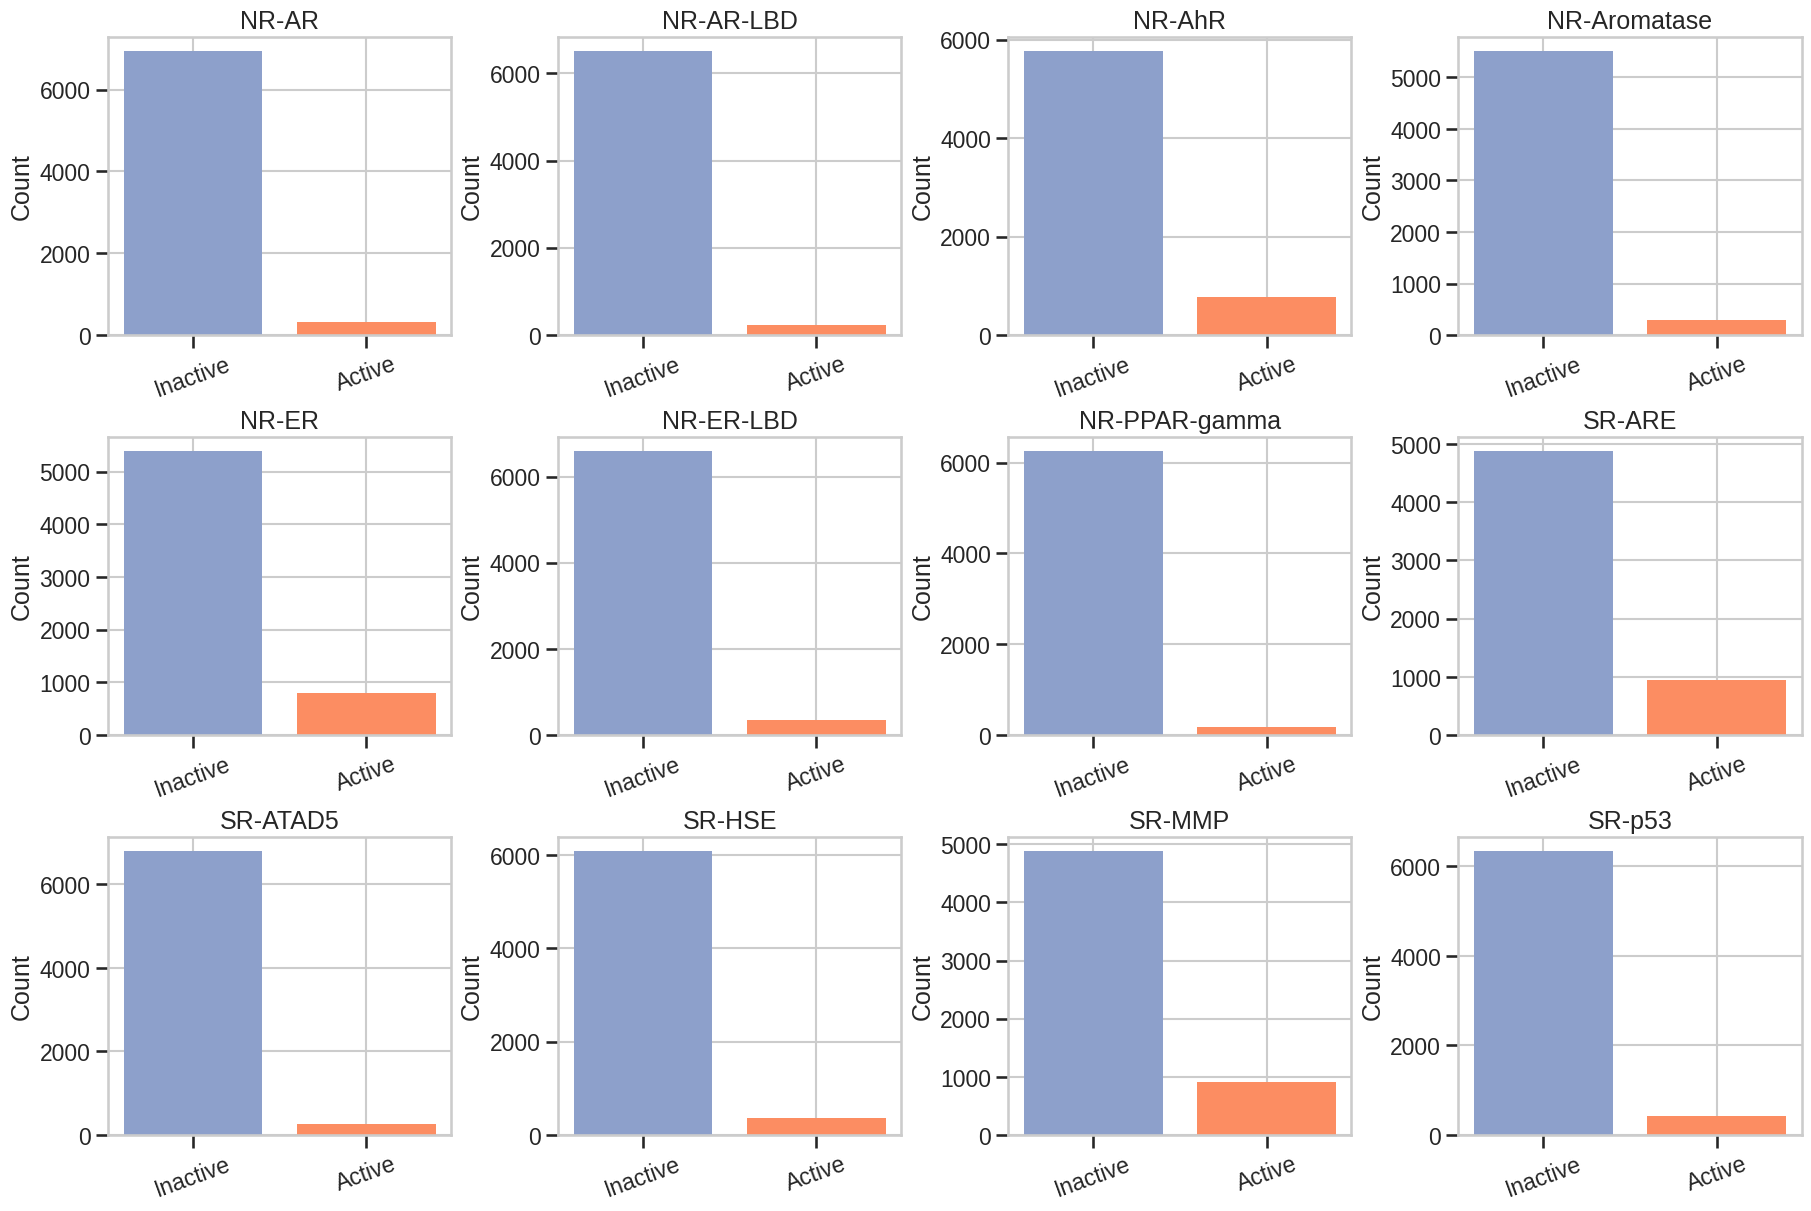

,labels_available,positives,negatives,negative_to_positive_ratio,positive_rate
NR-PPAR-gamma,6443,186,6257,33.639785,0.028869
NR-AR-LBD,6751,237,6514,27.485232,0.035106
SR-ATAD5,7065,264,6801,25.761364,0.037367
NR-AR,7258,308,6950,22.564935,0.042436
NR-ER-LBD,6948,349,6599,18.908309,0.050230
NR-Aromatase,5815,300,5515,18.383333,0.051591
SR-HSE,6460,372,6088,16.365591,0.057585
SR-p53,6767,423,6344,14.997636,0.062509
NR-AhR,6542,768,5774,7.518229,0.117395
NR-ER,6186,791,5395,6.820480,0.127869


In [15]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12), constrained_layout=True)
axes = axes.flatten()

for axis, task in zip(axes, task_cols):
    counts = work_df[task].value_counts(dropna=True).reindex([0, 1], fill_value=0)
    axis.bar(["Inactive", "Active"], counts.values, color=["#8da0cb", "#fc8d62"])
    axis.set_title(task)
    axis.set_ylabel("Count")
    axis.tick_params(axis="x", rotation=20)

for axis in axes[len(task_cols):]:
    axis.axis("off")

plt.show()

imbalance_table = pd.DataFrame(index=task_cols)
imbalance_table["labels_available"] = work_df[task_cols].notna().sum(axis=0)
imbalance_table["positives"] = (work_df[task_cols] == 1).sum(axis=0)
imbalance_table["negatives"] = (work_df[task_cols] == 0).sum(axis=0)
imbalance_table["negative_to_positive_ratio"] = imbalance_table["negatives"] / imbalance_table["positives"].replace(0, np.nan)
imbalance_table["positive_rate"] = imbalance_table["positives"] / imbalance_table["labels_available"]
display(imbalance_table.sort_values("positive_rate"))

## 4. Task-wise Random Forest baseline

Each toxicity endpoint is trained as its own binary classification problem. The model is fit on the task-specific training labels only, with SMOTEENN applied to the training fold when both classes are present in sufficient quantity.

In [16]:
def prepare_task_data(task_name: str):
    y = work_df[task_name].to_numpy(dtype=float)
    labeled_mask = ~np.isnan(y)
    labeled_indices = np.where(labeled_mask)[0]
    train_mask = np.isin(labeled_indices, train_idx)
    valid_mask = np.isin(labeled_indices, valid_idx)
    test_mask = np.isin(labeled_indices, test_idx)

    task_train_indices = labeled_indices[train_mask]
    task_valid_indices = labeled_indices[valid_mask]
    task_test_indices = labeled_indices[test_mask]

    y_train = y[task_train_indices].astype(int)
    y_valid = y[task_valid_indices].astype(int)
    y_test = y[task_test_indices].astype(int)

    X_train = X_all[task_train_indices]
    X_valid = X_all[task_valid_indices]
    X_test = X_all[task_test_indices]

    return {
        "train_indices": task_train_indices,
        "valid_indices": task_valid_indices,
        "test_indices": task_test_indices,
        "X_train": X_train,
        "X_valid": X_valid,
        "X_test": X_test,
        "y_train": y_train,
        "y_valid": y_valid,
        "y_test": y_test,
    }


def fit_random_forest_with_smoteenn(X_train, y_train):
    y_train = np.asarray(y_train)
    if len(np.unique(y_train)) < 2:
        model = RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        model.fit(X_train, y_train)
        return model, False

    minority_count = int(np.bincount(y_train).min())
    if minority_count < 2:
        model = RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        model.fit(X_train, y_train)
        return model, False

    k_neighbors = min(5, minority_count - 1)
    sampler = SMOTEENN(random_state=RANDOM_STATE, smote=None)
    try:
        from imblearn.over_sampling import SMOTE
        sampler = SMOTEENN(
            random_state=RANDOM_STATE,
            smote=SMOTE(k_neighbors=k_neighbors, random_state=RANDOM_STATE),
        )
        X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)
    except Exception:
        X_resampled, y_resampled = X_train, y_train

    model = RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    model.fit(X_resampled, y_resampled)
    return model, True


baseline_rows = []
task_artifacts = {}

for task_name in task_cols:
    task_data = prepare_task_data(task_name)
    y_train = task_data["y_train"]
    y_valid = task_data["y_valid"]
    y_test = task_data["y_test"]

    if len(np.unique(y_train)) < 2:
        baseline_rows.append({
            "task": task_name,
            "n_train": len(y_train),
            "n_valid": len(y_valid),
            "n_test": len(y_test),
            "valid_roc_auc": np.nan,
            "test_roc_auc": np.nan,
            "valid_accuracy": np.nan,
            "test_accuracy": np.nan,
            "valid_precision": np.nan,
            "test_precision": np.nan,
            "valid_recall": np.nan,
            "test_recall": np.nan,
            "smoteenn_used": False,
            "note": "single-class training split",
        })
        continue

    model, used_smoteenn = fit_random_forest_with_smoteenn(task_data["X_train"], y_train)

    valid_prob = model.predict_proba(task_data["X_valid"])[:, 1] if len(y_valid) else np.array([])
    test_prob = model.predict_proba(task_data["X_test"])[:, 1] if len(y_test) else np.array([])
    valid_pred = (valid_prob >= 0.5).astype(int) if len(valid_prob) else np.array([])
    test_pred = (test_prob >= 0.5).astype(int) if len(test_prob) else np.array([])

    baseline_rows.append({
        "task": task_name,
        "n_train": len(y_train),
        "n_valid": len(y_valid),
        "n_test": len(y_test),
        "valid_roc_auc": safe_auc_score(y_valid, valid_prob),
        "test_roc_auc": safe_auc_score(y_test, test_prob),
        "valid_accuracy": accuracy_score(y_valid, valid_pred) if len(y_valid) else np.nan,
        "test_accuracy": accuracy_score(y_test, test_pred) if len(y_test) else np.nan,
        "valid_precision": precision_score(y_valid, valid_pred, zero_division=0) if len(y_valid) else np.nan,
        "test_precision": precision_score(y_test, test_pred, zero_division=0) if len(y_test) else np.nan,
        "valid_recall": recall_score(y_valid, valid_pred, zero_division=0) if len(y_valid) else np.nan,
        "test_recall": recall_score(y_test, test_pred, zero_division=0) if len(y_test) else np.nan,
        "smoteenn_used": used_smoteenn,
        "note": "ok",
    })

    task_artifacts[task_name] = {
        **task_data,
        "model": model,
        "valid_prob": valid_prob,
        "test_prob": test_prob,
        "valid_pred": valid_pred,
        "test_pred": test_pred,
    }

results_df = pd.DataFrame(baseline_rows)
results_df = results_df.sort_values("test_roc_auc", ascending=False)
display(results_df)

valid_mean = results_df["valid_roc_auc"].mean(skipna=True)
test_mean = results_df["test_roc_auc"].mean(skipna=True)
print(f"Mean validation ROC-AUC: {valid_mean:.3f}" if pd.notna(valid_mean) else "Mean validation ROC-AUC: n/a")
print(f"Mean test ROC-AUC: {test_mean:.3f}" if pd.notna(test_mean) else "Mean test ROC-AUC: n/a")

,task,n_train,n_valid,n_test,valid_roc_auc,test_roc_auc,valid_accuracy,test_accuracy,valid_precision,test_precision,valid_recall,test_recall,smoteenn_used,note
1,NR-AR-LBD,5506,615,630,0.736819,0.872556,0.954472,0.957143,0.310345,0.382353,0.529412,0.684211,True,ok
2,NR-AhR,5300,623,619,0.794824,0.811069,0.805778,0.791599,0.417808,0.401361,0.628866,0.590000,True,ok
6,NR-PPAR-gamma,5306,580,557,0.628393,0.799445,0.922414,0.942549,0.217391,0.136364,0.156250,0.187500,True,ok
5,NR-ER-LBD,5649,653,646,0.730469,0.766820,0.917305,0.913313,0.196078,0.270833,0.434783,0.382353,True,ok
10,SR-MMP,4772,513,519,0.755290,0.761594,0.693957,0.724470,0.356757,0.350000,0.634615,0.589474,True,ok
8,SR-ATAD5,5740,652,673,0.711941,0.747201,0.900307,0.904903,0.146341,0.145833,0.166667,0.233333,True,ok
11,SR-p53,5517,627,623,0.684055,0.740579,0.835726,0.871589,0.196429,0.343284,0.159420,0.389831,True,ok
3,NR-Aromatase,4794,517,504,0.580673,0.697449,0.841393,0.843254,0.106383,0.152174,0.111111,0.148936,True,ok
9,SR-HSE,5308,573,579,0.672139,0.667113,0.888307,0.880829,0.227273,0.196078,0.250000,0.263158,True,ok
4,NR-ER,5081,548,557,0.693733,0.665233,0.731752,0.712747,0.282051,0.245399,0.556962,0.519481,True,ok


Mean validation ROC-AUC: 0.686
Mean test ROC-AUC: 0.734


## 5. Metrics and visualizations

This section summarizes the task-wise performance, shows ROC curves for the strongest tasks, and inspects the most important fingerprint bits for the best Random Forest model.

,task,n_train,n_valid,n_test,test_roc_auc,test_accuracy,test_precision,test_recall,smoteenn_used
1,NR-AR-LBD,5506,615,630,0.872556,0.957143,0.382353,0.684211,True
2,NR-AhR,5300,623,619,0.811069,0.791599,0.401361,0.590000,True
6,NR-PPAR-gamma,5306,580,557,0.799445,0.942549,0.136364,0.187500,True
5,NR-ER-LBD,5649,653,646,0.766820,0.913313,0.270833,0.382353,True
10,SR-MMP,4772,513,519,0.761594,0.724470,0.350000,0.589474,True
8,SR-ATAD5,5740,652,673,0.747201,0.904903,0.145833,0.233333,True
11,SR-p53,5517,627,623,0.740579,0.871589,0.343284,0.389831,True
3,NR-Aromatase,4794,517,504,0.697449,0.843254,0.152174,0.148936,True
9,SR-HSE,5308,573,579,0.667113,0.880829,0.196078,0.263158,True
4,NR-ER,5081,548,557,0.665233,0.712747,0.245399,0.519481,True


Mean task-wise test ROC-AUC: 0.734


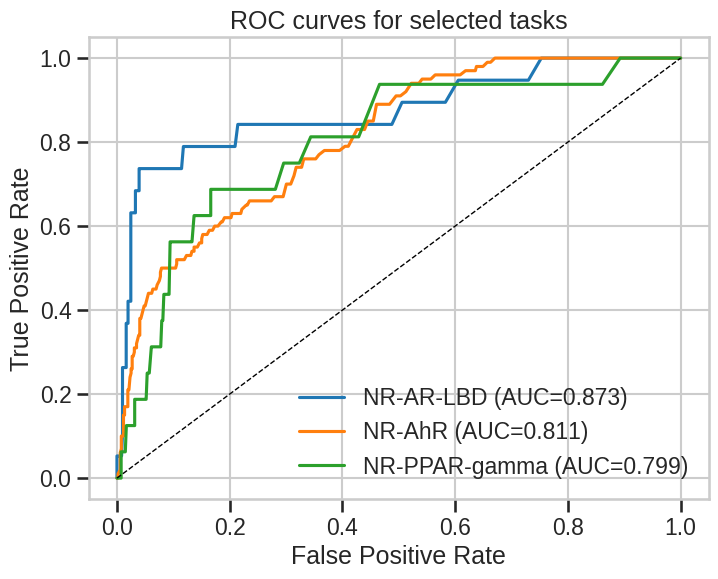

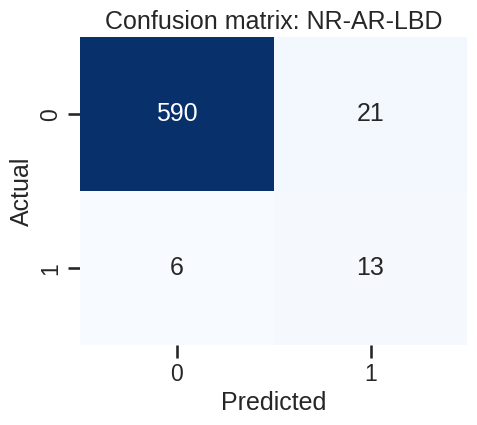

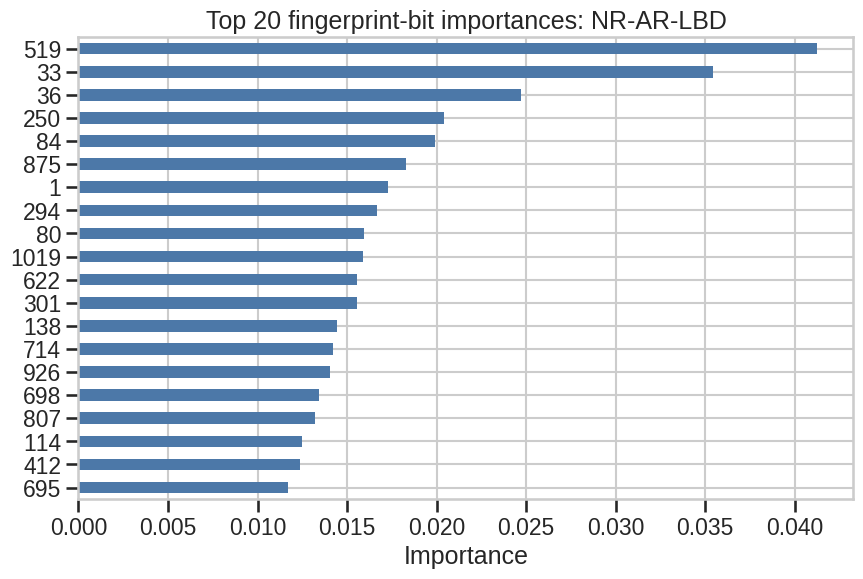

In [17]:
evaluated = results_df.dropna(subset=["test_roc_auc"]).copy()
if len(evaluated) > 0:
    evaluated = evaluated.sort_values("test_roc_auc", ascending=False)
    display(evaluated[["task", "n_train", "n_valid", "n_test", "test_roc_auc", "test_accuracy", "test_precision", "test_recall", "smoteenn_used"]])
    mean_test_auc = evaluated["test_roc_auc"].mean()
    print(f"Mean task-wise test ROC-AUC: {mean_test_auc:.3f}")
else:
    print("No task produced a valid ROC-AUC.")

# ROC curves for the top 3 tasks
fig, ax = plt.subplots(figsize=(8, 6))
for task_name in evaluated.head(3)["task"]:
    task_artifact = task_artifacts[task_name]
    if len(np.unique(task_artifact["y_test"])) < 2:
        continue
    fpr, tpr, _ = roc_curve(task_artifact["y_test"], task_artifact["test_prob"])
    auc_score = roc_auc_score(task_artifact["y_test"], task_artifact["test_prob"])
    ax.plot(fpr, tpr, label=f"{task_name} (AUC={auc_score:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curves for selected tasks")
ax.legend(loc="lower right")
plt.show()

# Confusion matrix for the best task with at least one positive and one negative in the test split
primary_task = None
for candidate_task in evaluated["task"]:
    candidate_artifact = task_artifacts[candidate_task]
    if len(np.unique(candidate_artifact["y_test"])) == 2:
        primary_task = candidate_task
        break

if primary_task is not None:
    primary_artifact = task_artifacts[primary_task]
    cm = confusion_matrix(primary_artifact["y_test"], primary_artifact["test_pred"])
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"Confusion matrix: {primary_task}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    rf_model = primary_artifact["model"]
    feature_importance = pd.Series(rf_model.feature_importances_).sort_values(ascending=False).head(20)
    plt.figure(figsize=(10, 6))
    feature_importance.iloc[::-1].plot(kind="barh", color="#4c78a8")
    plt.title(f"Top 20 fingerprint-bit importances: {primary_task}")
    plt.xlabel("Importance")
    plt.show()
else:
    print("Could not find a task with a valid binary test split for the confusion matrix.")

## 6. Optional XGBoost comparison

Random Forest is the main baseline. If XGBoost is available in the environment, the notebook also evaluates it on the best-scoring task as a lightweight comparison.

In [18]:
if XGBClassifier is None:
    print("XGBoost is not installed in this environment.")
elif primary_task is None:
    print("No primary task was selected for comparison.")
else:
    xgb_artifact = task_artifacts[primary_task]
    X_train = xgb_artifact["X_train"]
    y_train = xgb_artifact["y_train"]
    X_test = xgb_artifact["X_test"]
    y_test = xgb_artifact["y_test"]

    if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
        print(f"Skipping XGBoost for {primary_task} because one split has only one class.")
    else:
        xgb_model = XGBClassifier(
            n_estimators=250,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            objective="binary:logistic",
            eval_metric="auc",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            tree_method="hist",
        )
        xgb_model.fit(X_train, y_train)
        xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
        xgb_pred = (xgb_prob >= 0.5).astype(int)
        xgb_auc = safe_auc_score(y_test, xgb_prob)
        print(f"XGBoost comparison for {primary_task}")
        print(f"Test ROC-AUC: {xgb_auc:.3f}")
        print(f"Test accuracy: {accuracy_score(y_test, xgb_pred):.3f}")
        print(f"Test precision: {precision_score(y_test, xgb_pred, zero_division=0):.3f}")
        print(f"Test recall: {recall_score(y_test, xgb_pred, zero_division=0):.3f}")

XGBoost comparison for NR-AR-LBD
Test ROC-AUC: 0.806
Test accuracy: 0.979
Test precision: 0.800
Test recall: 0.421


In [19]:
pip install optuna joblib

Note: you may need to restart the kernel to use updated packages.


In [21]:
import joblib
import optuna

In [22]:
def resample_with_smoteenn(X_train, y_train):
    y_train = np.asarray(y_train)
    unique_classes = np.unique(y_train)
    if len(unique_classes) < 2:
        return X_train, y_train, False

    minority_count = int(np.bincount(y_train).min())
    if minority_count < 2:
        return X_train, y_train, False

    k_neighbors = min(5, minority_count - 1)
    try:
        from imblearn.over_sampling import SMOTE
        sampler = SMOTEENN(
            random_state=RANDOM_STATE,
            smote=SMOTE(k_neighbors=k_neighbors, random_state=RANDOM_STATE),
        )
        X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)
        return X_resampled, y_resampled, True
    except Exception:
        return X_train, y_train, False


if primary_task is None:
    print("No primary task was selected earlier, so comparison cannot run.")
else:
    comparison_artifact = task_artifacts[primary_task]
    X_train = comparison_artifact["X_train"]
    y_train = comparison_artifact["y_train"]
    X_valid = comparison_artifact["X_valid"]
    y_valid = comparison_artifact["y_valid"]
    X_test = comparison_artifact["X_test"]
    y_test = comparison_artifact["y_test"]

    X_train_bal, y_train_bal, used_smoteenn = resample_with_smoteenn(X_train, y_train)
    print(f"SMOTEENN used: {used_smoteenn}")

    comparison_rows = []

    rf_compare = RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    rf_compare.fit(X_train_bal, y_train_bal)
    rf_valid_prob = rf_compare.predict_proba(X_valid)[:, 1]
    rf_test_prob = rf_compare.predict_proba(X_test)[:, 1]
    comparison_rows.append({
        "model": "RandomForest",
        "valid_roc_auc": safe_auc_score(y_valid, rf_valid_prob),
        "test_roc_auc": safe_auc_score(y_test, rf_test_prob),
        "valid_accuracy": accuracy_score(y_valid, (rf_valid_prob >= 0.5).astype(int)),
        "test_accuracy": accuracy_score(y_test, (rf_test_prob >= 0.5).astype(int)),
    })

    if XGBClassifier is not None:
        xgb_compare = XGBClassifier(
            n_estimators=250,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            objective="binary:logistic",
            eval_metric="auc",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            tree_method="hist",
        )
        xgb_compare.fit(X_train_bal, y_train_bal)
        xgb_valid_prob = xgb_compare.predict_proba(X_valid)[:, 1]
        xgb_test_prob = xgb_compare.predict_proba(X_test)[:, 1]
        comparison_rows.append({
            "model": "XGBoost",
            "valid_roc_auc": safe_auc_score(y_valid, xgb_valid_prob),
            "test_roc_auc": safe_auc_score(y_test, xgb_test_prob),
            "valid_accuracy": accuracy_score(y_valid, (xgb_valid_prob >= 0.5).astype(int)),
            "test_accuracy": accuracy_score(y_test, (xgb_test_prob >= 0.5).astype(int)),
        })
    else:
        print("XGBoost unavailable; only RandomForest was compared.")

    comparison_df = pd.DataFrame(comparison_rows).sort_values("valid_roc_auc", ascending=False)
    display(comparison_df)
    best_family = comparison_df.iloc[0]["model"]
    print(f"Baseline winner by validation ROC-AUC: {best_family}")

SMOTEENN used: True


,model,valid_roc_auc,test_roc_auc,valid_accuracy,test_accuracy
0,RandomForest,0.736819,0.872556,0.954472,0.957143
1,XGBoost,0.706276,0.832113,0.920325,0.912698


Baseline winner by validation ROC-AUC: RandomForest


In [23]:
if optuna is None:
    print("Optuna is not available in this environment.")
elif primary_task is None:
    print("No primary task was selected earlier, so tuning cannot run.")
else:
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    tuning_artifact = task_artifacts[primary_task]
    X_train = tuning_artifact["X_train"]
    y_train = tuning_artifact["y_train"]
    X_valid = tuning_artifact["X_valid"]
    y_valid = tuning_artifact["y_valid"]
    X_test = tuning_artifact["X_test"]
    y_test = tuning_artifact["y_test"]

    X_train_bal, y_train_bal, _ = resample_with_smoteenn(X_train, y_train)

    def objective_rf(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 200, 500),
            "max_depth": trial.suggest_int("max_depth", 4, 20),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),
            "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
            "class_weight": "balanced",
            "random_state": RANDOM_STATE,
            "n_jobs": -1,
        }
        model = RandomForestClassifier(**params)
        model.fit(X_train_bal, y_train_bal)
        prob = model.predict_proba(X_valid)[:, 1]
        return safe_auc_score(y_valid, prob)

    def objective_xgb(trial):
        if XGBClassifier is None:
            raise optuna.TrialPruned()
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 150, 400),
            "max_depth": trial.suggest_int("max_depth", 3, 8),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
            "subsample": trial.suggest_float("subsample", 0.7, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
            "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 8.0),
            "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 5.0),
            "objective": "binary:logistic",
            "eval_metric": "auc",
            "random_state": RANDOM_STATE,
            "n_jobs": -1,
            "tree_method": "hist",
        }
        model = XGBClassifier(**params)
        model.fit(X_train_bal, y_train_bal)
        prob = model.predict_proba(X_valid)[:, 1]
        return safe_auc_score(y_valid, prob)

    n_trials = 12
    rf_study = optuna.create_study(direction="maximize", study_name="rf_tox21")
    rf_study.optimize(objective_rf, n_trials=n_trials)
    print("Best RF validation ROC-AUC:", round(rf_study.best_value, 4))
    print("Best RF params:", rf_study.best_params)

    xgb_study = None
    if XGBClassifier is not None:
        xgb_study = optuna.create_study(direction="maximize", study_name="xgb_tox21")
        xgb_study.optimize(objective_xgb, n_trials=n_trials)
        print("Best XGB validation ROC-AUC:", round(xgb_study.best_value, 4))
        print("Best XGB params:", xgb_study.best_params)

    study_results = []
    study_results.append({"model": "RandomForest", "best_valid_auc": rf_study.best_value, "best_params": rf_study.best_params})
    if xgb_study is not None:
        study_results.append({"model": "XGBoost", "best_valid_auc": xgb_study.best_value, "best_params": xgb_study.best_params})
    study_results_df = pd.DataFrame(study_results).sort_values("best_valid_auc", ascending=False)
    display(study_results_df)

    best_model_family = study_results_df.iloc[0]["model"]
    best_params = study_results_df.iloc[0]["best_params"]
    print(f"Selected best tuned model: {best_model_family}")

    X_fit = np.vstack([X_train, X_valid])
    y_fit = np.concatenate([y_train, y_valid])
    X_fit_bal, y_fit_bal, used_smoteenn_final = resample_with_smoteenn(X_fit, y_fit)

    if best_model_family == "RandomForest":
        final_model = RandomForestClassifier(
            **best_params,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    else:
        final_model = XGBClassifier(
            **best_params,
            objective="binary:logistic",
            eval_metric="auc",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            tree_method="hist",
        )

    final_model.fit(X_fit_bal, y_fit_bal)
    final_test_prob = final_model.predict_proba(X_test)[:, 1]
    final_test_pred = (final_test_prob >= 0.5).astype(int)
    final_test_auc = safe_auc_score(y_test, final_test_prob)
    print(f"Final tuned model test ROC-AUC: {final_test_auc:.4f}")
    print(f"Final tuned model test accuracy: {accuracy_score(y_test, final_test_pred):.4f}")
    print(f"Final tuned model test precision: {precision_score(y_test, final_test_pred, zero_division=0):.4f}")
    print(f"Final tuned model test recall: {recall_score(y_test, final_test_pred, zero_division=0):.4f}")

    best_bundle = {
        "task": primary_task,
        "model_family": best_model_family,
        "model": final_model,
        "best_params": best_params,
        "feature_type": "morgan_fingerprint",
        "radius": RADIUS,
        "n_bits": N_BITS,
        "random_state": RANDOM_STATE,
        "smoteenn_used": used_smoteenn_final,
        "test_roc_auc": final_test_auc,
    }
    best_model_path = "tox21_best_tuned_model.joblib"
    joblib.dump(best_bundle, best_model_path)
    print(f"Saved tuned model bundle to: {best_model_path}")


Best RF validation ROC-AUC: 0.752
Best RF params: {'n_estimators': 355, 'max_depth': 20, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': None}
Best XGB validation ROC-AUC: 0.7117
Best XGB params: {'n_estimators': 381, 'max_depth': 7, 'learning_rate': 0.19398475611172053, 'subsample': 0.762281490750416, 'colsample_bytree': 0.9267033329678959, 'min_child_weight': 4.208868617266953, 'reg_lambda': 2.691333593955965}


,model,best_valid_auc,best_params
0,RandomForest,0.751967,"{'n_estimators': 355, 'max_depth': 20, 'min_samples_split': 10, 'min_samples..."
1,XGBoost,0.711686,"{'n_estimators': 381, 'max_depth': 7, 'learning_rate': 0.19398475611172053, ..."


Selected best tuned model: RandomForest
Final tuned model test ROC-AUC: 0.8026
Final tuned model test accuracy: 0.9238
Final tuned model test precision: 0.2264
Final tuned model test recall: 0.6316


FileNotFoundError: [Errno 2] No such file or directory: 'models/tox21_best_tuned_model.joblib'

In [26]:
best_model_path = "tox21_best_tuned_model.joblib"
joblib.dump(best_bundle, best_model_path)
print(f"Saved tuned model bundle to: {best_model_path}")
if 'best_model_path' not in globals():
    print("No saved model bundle was created yet. Run the Optuna tuning cell first.")
else:
    loaded_bundle = joblib.load(best_model_path)
    print(f"Loaded model family: {loaded_bundle['model_family']}")
    print(f"Loaded task: {loaded_bundle['task']}")

    new_data = pd.DataFrame({
        "compound_name": ["benzene_like", "anilide_like", "alcohol_like"],
        "smiles": ["c1ccccc1", "CC(C)(C1=CC=C(C=C1)O)C2=CC=C(C=C2)O", "CCO"],
    })

    new_data["mol"] = new_data["smiles"].map(smiles_to_mol)
    new_data["valid_smiles"] = new_data["mol"].notna()
    new_data = new_data[new_data["valid_smiles"]].reset_index(drop=True)

    new_features = make_morgan_matrix(new_data["smiles"])
    predicted_prob = loaded_bundle["model"].predict_proba(new_features)[:, 1]
    predicted_label = (predicted_prob >= 0.5).astype(int)

    new_data[f"{loaded_bundle['task']}_probability"] = predicted_prob
    new_data[f"{loaded_bundle['task']}_prediction"] = predicted_label
    display(new_data[["compound_name", "smiles", f"{loaded_bundle['task']}_probability", f"{loaded_bundle['task']}_prediction"]])

    print("Interpretation: probabilities closer to 1 indicate a higher predicted chance of activity for the selected toxicity endpoint.")

Saved tuned model bundle to: tox21_best_tuned_model.joblib
Loaded model family: RandomForest
Loaded task: NR-AR-LBD


,compound_name,smiles,NR-AR-LBD_probability,NR-AR-LBD_prediction
0,benzene_like,c1ccccc1,0.890041,1
1,anilide_like,CC(C)(C1=CC=C(C=C1)O)C2=CC=C(C=C2)O,0.000492,0
2,alcohol_like,CCO,0.683529,1


Interpretation: probabilities closer to 1 indicate a higher predicted chance of activity for the selected toxicity endpoint.


## 7. Conclusion

This notebook provides a strict scaffold-split baseline for Tox21 using ECFP fingerprints and task-wise Random Forest models. The results are a realistic starting point for further tuning, descriptor engineering, or more advanced multi-task methods.